In [31]:
import numpy as np
from sklearn.linear_model import LogisticRegression

def sigma(x):
    res = np.exp(x) / (1 + np.exp(x))
    return res

# TASK 1
# params
n = 1000
k = 20
p = 5 + k
b = 0.5
alpha = 1

X = np.zeros((n, p))
for j in np.arange(0, p, 1):
    X[:, j] = np.random.normal(loc=0, scale=1, size=n)

beta_true = np.zeros(p)
beta_true[0:5] = b
eta = alpha + np.dot(X, beta_true)
prob_true = sigma(eta)

y = np.zeros(n)
for i in np.arange(0, n, 1):
    y[i] = np.random.binomial(1, prob_true[i], size=1)[0]

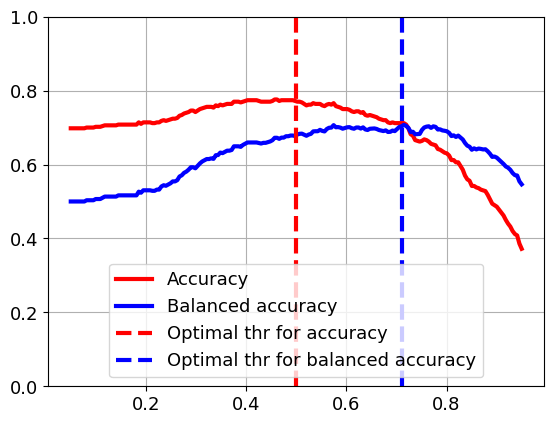

In [32]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# TASK 3
X1, X2, y1, y2 = train_test_split(X, y, test_size=0.5, random_state=42)

model = LogisticRegression()
model.fit(X1, y1)
prob2 = model.predict_proba(X2)[:, 1]

acc = np.zeros(200)
bacc = np.zeros(200)
rec = np.zeros(200)
prec = np.zeros(200)
t_seq = np.linspace(start=0.05, stop=0.95, num=200)

k = 0
for t in t_seq:
    y2_pred = np.where(prob2 > t, 1, 0)

    acc[k] = accuracy_score(y2, y2_pred)
    bacc[k] = balanced_accuracy_score(y2, y2_pred)
    rec[k] = recall_score(y2, y2_pred)
    prec[k] = precision_score(y2, y2_pred)

    k = k+1

plt.style.use("default")
plt.rcParams.update({"font.size": 13})
plt.plot(t_seq, acc, color="r", label="Accuracy", linewidth=3)
plt.plot(t_seq, bacc, color="b", label="Balanced accuracy", linewidth=3)
plt.axvline(x=0.5, color="r", label="Optimal thr for accuracy", linestyle="dashed", linewidth=3)
plt.axvline(x=np.mean(y1), color="b", label="Optimal thr for balanced accuracy", linestyle="dashed", linewidth=3)
plt.legend(loc="lower center")
plt.ylim(0, 1)
plt.grid(which="both")
plt.show()

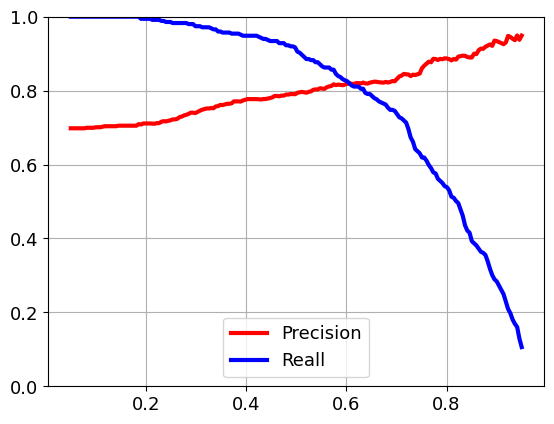

In [33]:
plt.style.use("default")
plt.rcParams.update({"font.size": 13})
plt.plot(t_seq, prec, color="r", label="Precision", linewidth=3)
plt.plot(t_seq, rec, color="b", label="Reall", linewidth=3)
plt.legend(loc="lower center")
plt.ylim(0, 1)
plt.grid(which="both")
plt.show()

In [34]:
# TASK 2
model = LogisticRegression()

In [35]:
# refitting
model.fit(X, y)
y_pred = model.predict(X)
err = np.mean(y_pred != y)
err


0.228

In [36]:
# 10-fold cross-validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=10)
err = np.mean(1 - scores)
err

0.24399999999999994

In [ ]:
# bootstrap
sample_num = 10

for i in range(sample_num):
    indices = np.random.choice(X.shape[0], size=X.shape[0], replace=True)
    X_sample = X[indices]
    y_sample = y[indices]

    model = LogisticRegression()
    model.fit(X_sample, y_sample)
    